# Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

# Import util functions
from src.modelling_utils import (
                                get_classification_metrics,
                                train_test_with_groups_and_pca, 
                                train_models_with_cv, 
                                adjust_pr_curve_from_roc
                                )
from src.results_utils import (
                                get_cv_results,
                                extract_summaries_and_save,
                                get_summaries
                                )
from src.plotting_utils import plot_precision_recall_curve, plot_roc_curve
from src.general_utils import combine_train_test_metrics

from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier

RANDOM_STATE = 4 # For reproducibility

# Introduction

In this notebook, we are going to make feature selection with 2 methods:
1. **L1 Regularization with Logistic Regression:**  Coefficients' absolute values can be used to rank features. This method is usefull for linear models, since logistic regression is a linear model. Non-linear models full potential can be unlocked with features selected only by this method. That's why we are going to add a second method.
2. **Feature Importance with Gradient Boosting:** Tree based models produce feature importance values according to their performance to predict target. Features selected with this way would more appropriate for non-linear models than features selected with L1 Regularization.

Eventually, we are going to select two set of ranked features. At the end, we are going to analyze them and select two set of features for linear and non-linear models. Before we select features, we need to select a hyperparameter set for each model. We are going to do it by *grid search cross validation*.

**!** The reason we choose these two methods rather than others is that, they are easy to execute and effective enough for our main task.

---

## About Performance Metrics

First things first, we need to choose performance metrics for our main prediction task.

**Primary Performance Metrics:**

* **Precision-Recall Curve and Area Under the Curve:** This is our main metric. The reasons are; our prediction method is binary classification, and our task is predicting rare / extreme events. While this metric highly sensitive to imbalance between classes (like our context with *0.0368* positive event prevalence), it is the best metric for our task. We are going to compare **precision-recall area under the curve (PR-AUC)** values of models to make decisions.
*  **Adjusted PR-AUC:** This value is *test set's PR-AUC value if it would have same prevalance as train set's*. Why we need this one is: We are going to use cross validation all time, so we will be splitting data. Rare events are not regular in time, also climate changes are not very regular too. Also, our data is a time series data we can't use stratified split for our CV, but only time series split method. For this reasons splits' train and test sets' prevalances are tend to be different. To check overfitting / underfitting, spesifically we need to compare train and test sets' performances. That's why we are going to use **adjusted PR-AUC** metric. (Obviously this metric exists only for test set, train set's adjusted PR-AUC value is same with its normal PR-AUC value.) 

**Secondary Performance Metrics:**

* **ROC Curve and Area Under the Curve (ROC-AUC):** In binary classification, this metric is one of the main metrics. Shows model's discriminative power, in other words how well model can distinguish between classes. But, this metric's main disadvantage for our context is, it does not count on imbalance between classes. This is why we use it as a secondary metric. 

* **Precision and Recall Values:** These shows how well model performs from different perspectives. *Recall* is more important than *Precision* for our context, due to missing heatwaves are more crucial than false positives / alarms. The reason we think this as ourr secondary metrics is, they are adjustable by changing model's decision threshold. Thus, we use **PR-AUC**, these two metrics' combined form as our primary metric. Decision threshold subject is going to be taken in hand in future notebooks, spesifically after model selection.

**!!!** These are going to be our main metrics and all together, it is going to be *main evaluation strategy all along rest of the project*. Not just for this notebook.

---

Now we've taken care of requisite subjects, we can get into action.

# Data Loading and Initial Processing

In [2]:
# Loading all possible features set
all_feats_df = pd.read_csv("data/processed/daily_all_features.csv", index_col="datetime_local")
all_feats_df.index = pd.to_datetime(all_feats_df.index, utc=True).tz_convert("Australia/Adelaide")
all_feats_df.head()

,relative_humidity_2m,dew_point_2m,apparent_temperature,pressure_msl,wind_speed_10m,cloud_cover,shortwave_radiation,wet_bulb_temperature_2m,month_local,wind_unit_x,...,month_cyc_x,month_cyc_y,DMT_month_mean,tmin_month_mean,tmax_month_mean,EHF_month_mean,EHI_sig_month_mean,EHF_sev_month_mean,relative_humidity_2m_month_mean,DMT_avg30
datetime_local,,,,,,,,,,,,,,,,,,,,,
2000-01-01 00:00:00+10:30,58.375954,6.854583,11.690625,1018.404172,22.481411,25.791667,338.208333,10.507936,1.0,-0.859000,...,0.866025,0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-02 00:00:00+10:30,53.894292,8.606667,17.562999,1014.966667,13.889992,17.791667,381.666667,13.051835,1.0,-0.590170,...,0.866025,0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-03 00:00:00+10:30,59.922957,10.537917,17.466684,1013.208338,17.923586,18.916667,377.500000,14.051188,1.0,-0.738965,...,0.866025,0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-04 00:00:00+10:30,51.373941,5.492083,11.487354,1020.416664,27.433249,17.791667,379.583333,10.278888,1.0,-0.985043,...,0.866025,0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-05 00:00:00+10:30,54.446861,6.762917,12.839374,1022.775004,21.999236,32.166667,361.125000,10.918418,1.0,-0.904516,...,0.866025,0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# Loading feature groups for classification
fg_cls= pd.read_csv('data/modelling_info/fg_cls.csv')
fg_cls

,feature_group,group_size,cumulative_pve,to_be_used_pcs
0,"['precipitation_sum7', 'precipitation_std7']",2,"[0.9635903670948435, 1.0]",1
1,"['precipitation_sum3', 'precipitation_std3']",2,"[0.9519504301550225, 0.9999999999999999]",1
2,"['wind_speed_10m_lag2', 'wind_speed_10m_avg3']",2,"[0.9269007706676774, 0.9999999999999999]",1
3,"['EHI_accl_lag3', 'EHI_accl_lag4']",2,"[0.9302000255077699, 1.0]",1
4,"['DMT_std3', 'tmax_std3']",2,"[0.9459727593038323, 1.0]",1
5,"['pressure_msl_lag1', 'pressure_msl_lag2', 'pr...",3,"[0.909740388413776, 0.9902699932238705, 1.0]",1
6,"['pressure_msl_lag3', 'pressure_msl_avg7']",2,"[0.8955354159430747, 0.9999999999999999]",1
7,"['DMT_std7', 'tmin_std7', 'tmax_std7', 'EHI_si...",4,"[0.871257895032853, 0.9461741317268824, 0.9979...",1
8,"['EHF_lag3', 'EHF_avg3', 'EHF_avg7']",3,"[0.9143955048675078, 0.9651845997143979, 0.999...",1
9,"['EHF_lag4', 'EHF_lag5']",2,"[0.9182199172946198, 1.0000000000000002]",1


In [5]:
# Drop unusable columns:
unusable_cols = ['DMT', 'tmin', 'EHF', 'EHI_sig', 'EHI_accl', 'EHF_sev', 
                               'wind_direction_compass', 'month_local']
all_feats_df.drop(columns=unusable_cols, inplace=True)

Last two are categorical, their cyclical versions are already inclueded. Before them, main reason has discussed in the previous notebook. Simply, it is *data leakage*.

In [ ]:
# List cyclical features
non_standardized_features =  ['month_cyc_x', 'month_cyc_y']
for c in all_feats_df.columns:
    if c.startswith('wind_unit') and 'avg' in c:
        non_standardized_features.append(c)

non_standardized_features

['month_cyc_x',
 'month_cyc_y',
 'wind_unit_x_avg3',
 'wind_unit_x_avg7',
 'wind_unit_y_avg3',
 'wind_unit_y_avg7']

We don't want to disrupt their cyclical nature, model can learn them. Also, they are gathered around 0 evenly, so, they are like half standardized already. 

In [ ]:
all_feats_df.dropna(inplace=True)
y = all_feats_df['heat_wave']
X = all_feats_df.drop(columns=['severity', 'heat_wave'])
# Dropped rows with missing values and, seperated features and target.

# Train and test sets
X_train = X.loc[:'2020']
y_train = y.loc[:'2020']
X_test = X.loc['2021':'2024']
y_test = y.loc['2021':'2024']

**!! Another statement for full project:** We are going to use above train test split all along rest of the project.
* *Main Train Set*: $[2001, 2020]$ (Closed interval). (First year (2000) rows have missing values, so, they are dropped.)
* *Main Test Set*: $[2021, 2024]$ (Closed interval)

In [ ]:
print(f"Train start: {X_train.index.min()}, end: {X_train.index.max()}")
print(f"Test start: {X_test.index.min()}, end: {X_test.index.max()}")
# To be sure split points match

Train start: 2001-01-01 00:00:00+10:30, end: 2020-12-31 00:00:00+10:30
Test start: 2021-01-01 00:00:00+10:30, end: 2024-12-31 00:00:00+10:30


# Hyperparamet Tuning Before Feature Selection

We want to find best performing hyperparameters for each models before feature selection. We are going to use **Time Series Cross Validation** for that.

## Logistic Regression

In [17]:
logreg_param_grid = [
    {'name': 'LogReg',
     'model': LogisticRegression,
     'type': 'linear',
     'params': {
        'penalty': ['l1'],
        'solver': ['liblinear'],
        'C': [0.1, 1, 25, 50, 100],
        'random_state': [RANDOM_STATE]
        }
    }
]

In [18]:
# To be sure about reproducubility
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

train_models_with_cv(
    X_train=X_train,
    y_train=y_train,
    feature_groups_df=fg_cls,
    models_info_and_params=logreg_param_grid, # Or other grids
    non_standardized_features=non_standardized_features,
    not_to_be_used_at_linear=None,
    not_to_be_used_at_nonlinear=None,
    cv_splits = 5,
    results_path=f"data/modelling_info/logreg_cv_results.csv"
)

Model:  LogReg
Parameters:  {'C': 0.1, 'penalty': 'l1', 'random_state': 4, 'solver': 'liblinear'}
Parameters:  {'C': 1, 'penalty': 'l1', 'random_state': 4, 'solver': 'liblinear'}
Parameters:  {'C': 25, 'penalty': 'l1', 'random_state': 4, 'solver': 'liblinear'}
Parameters:  {'C': 50, 'penalty': 'l1', 'random_state': 4, 'solver': 'liblinear'}
Parameters:  {'C': 100, 'penalty': 'l1', 'random_state': 4, 'solver': 'liblinear'}


In [ ]:
logreg_cv_results = {'logreg': pd.read_csv('data/modelling_info/logreg_cv_results.csv')}

In [ ]:
# logreg_summary = extract_summaries_and_save(logreg_cv_results, dir="data/modelling_info")
logreg_summary = pd.read_csv('data/modelling_info/logreg_summary.csv')

In [11]:
logreg_summary.sort_values(by='tr_pr_auc_mean', ascending=False)

,params_C,tr_pr_auc_mean,tr_pr_auc_std,te_pr_auc_mean,te_pr_auc_std,adj_pr_auc_mean,adj_pr_auc_std,tr_roc_auc_mean,tr_roc_auc_std,te_roc_auc_mean,...,tr_recall_mean,tr_recall_std,te_recall_mean,te_recall_std,tr_precision_mean,tr_precision_std,te_precision_mean,te_precision_std,time_mean,time_std
2,25.0,0.8194,0.0138,0.6987,0.0586,0.6891,0.0846,0.9887,0.0019,0.9713,...,0.6453,0.0362,0.5456,0.1493,0.7819,0.0124,0.7003,0.0211,7.3741,1.8695
4,50.0,0.8194,0.0137,0.6985,0.0580,0.6888,0.0841,0.9887,0.0019,0.9712,...,0.6464,0.0369,0.5456,0.1493,0.7820,0.0117,0.7003,0.0211,7.8420,1.7728
3,100.0,0.8194,0.0137,0.6985,0.0576,0.6888,0.0839,0.9887,0.0019,0.9712,...,0.6453,0.0363,0.5456,0.1493,0.7818,0.0114,0.6929,0.0065,12.4407,2.3994
0,1.0,0.8097,0.0116,0.7134,0.0577,0.7040,0.0826,0.9881,0.0016,0.9746,...,0.6194,0.0231,0.5260,0.1322,0.7878,0.0129,0.7665,0.0695,1.4621,0.4152
1,0.1,0.7433,0.0159,0.7062,0.0634,0.6960,0.0887,0.9840,0.0011,0.9772,...,0.4931,0.0219,0.4304,0.1059,0.7852,0.0235,0.7976,0.0906,0.2700,0.0579


By looking `tr_roc_auc_mean`s and `test_roc_auc_mean`s, models has very slight overfitting, which is acceptable. `tr_pr_auc_mean`s and `test_pr_auc_mean`s differs more, but this is due to data being imbalanced. Which is not a problem. `C=25, 50` and `100` values all same and best. We take `C=25`, which has most regularization among three. Also for feature selection, `C=25` would elliminate more.

Let's check ``C=25`` train with whole train data and evaluate with test data.

In [19]:
logreg_c_25 = LogisticRegression(C=25, penalty='l1', solver='liblinear', random_state=RANDOM_STATE)

np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
(trained_model, 
metric_result_train, 
metric_result_test, 
artifacts) = train_test_with_groups_and_pca(
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    model=logreg_c_25,
    feature_groups_df=fg_cls,
    non_standardized_features=non_standardized_features,
    metric_fn=get_classification_metrics,
    metric_kwargs={'target_prevalence': y_train.value_counts(normalize=True)[True]}) # For Adjusted PR Curve
                                        

In [38]:
metrics_train, pr_auc_dict_train, roc_auc_dict_train = metric_result_train
metrics_test, pr_auc_dict_test, roc_auc_dict = metric_result_test

In [39]:
combine_train_test_metrics(metrics_train, metrics_test)

,train,test
recall,0.6019,0.6053
precision,0.7558,0.7667
pr_auc,0.7946,0.7267
roc_auc,0.9859,0.9829
pr_auc_adj,0.7946,0.7971


*Adjusted PR-AUC* and *ROC-AUC* values are same for both sets which is very good, shows that, model learned until ideal *bias-variance treshold*.

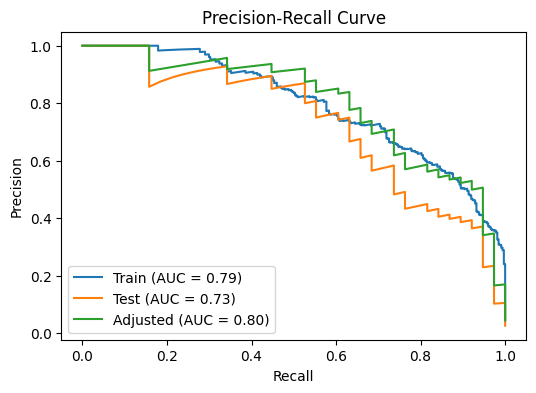

In [40]:
adjusted = adjust_pr_curve_from_roc(
    fpr=roc_auc_dict["fpr"],
    tpr=roc_auc_dict["tpr"],
    target_prevalence=y_train.value_counts(normalize=True)[True], # Train set prevalence
)
adjusted['name'] = "Adjusted"
pr_auc_dict_test['name'] = "Test"
pr_auc_dict_train['name'] = "Train"
plot_precision_recall_curve([pr_auc_dict_train, pr_auc_dict_test, adjusted])

Training with whole train data cleared slight overfitting too.

## Gradient Boosting

In [ ]:
gradboost_param_grid = [
    {'name': 'Gradient Boosting',
     'model': GradientBoostingClassifier,
     'type': 'nonlinear',
     'params': {
        'max_depth': [1, 2, 3, 5],
        'n_estimators': [50, 75, 100],
        'learning_rate': [0.1, 0.2, 0.3],
        'random_state': [RANDOM_STATE]
        }
    }
]

In [ ]:
# To be sure about reproducubility
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

train_models_with_cv(
    X_train=X_train,
    y_train=y_train,
    feature_groups_df=fg_cls,
    models_info_and_params=gradboost_param_grid, 
    non_standardized_features=non_standardized_features,
    not_to_be_used_at_linear=None,
    not_to_be_used_at_nonlinear=None,
    cv_splits = 5,
    results_path=f"data/modelling_info/gradboost_cv_results.csv"
)

**!** This top cell executed at *"Google Colab"* because of its high execution time.

In [2]:
gradboost_cv_results = {'gradboost': pd.read_csv('data/modelling_info/gradboost_cv_results.csv')}

In [49]:
# gradboost_summary = extract_summaries_and_save(gradboost_cv_results, folder='modelling_info', mid_word='')['gradboost']
gradboost_summary = pd.read_csv('data/modelling_info/gradboost_summary.csv')

In [ ]:
gradboost_summary

,params_learning_rate,params_max_depth,params_n_estimators,tr_pr_auc_mean,tr_pr_auc_std,te_pr_auc_mean,te_pr_auc_std,adj_pr_auc_mean,adj_pr_auc_std,tr_roc_auc_mean,...,tr_recall_mean,tr_recall_std,te_recall_mean,te_recall_std,tr_precision_mean,tr_precision_std,te_precision_mean,te_precision_std,time_mean,time_std
0,0.1,5.0,100.0,1.0000,0.0000,0.6997,0.0709,0.6869,0.0978,1.0000,...,1.0000,0.0000,0.4431,0.0985,1.0000,0.0000,0.7350,0.0651,35.9273,8.2662
1,0.1,5.0,75.0,1.0000,0.0000,0.6956,0.0698,0.6831,0.0968,1.0000,...,1.0000,0.0000,0.4439,0.0923,1.0000,0.0000,0.7443,0.0516,26.8028,6.1779
2,0.1,5.0,50.0,0.9999,0.0001,0.6903,0.0677,0.6766,0.0961,1.0000,...,0.9965,0.0059,0.4372,0.1059,0.9993,0.0015,0.7243,0.0707,17.9419,4.1497
3,0.1,2.0,75.0,0.8913,0.0308,0.6885,0.0846,0.6777,0.1092,0.9926,...,0.6626,0.0410,0.4284,0.0685,0.9144,0.0275,0.7186,0.1047,11.3168,2.3583
4,0.1,3.0,75.0,0.9799,0.0154,0.6874,0.0745,0.6792,0.0908,0.9988,...,0.8492,0.0448,0.4286,0.1033,0.9780,0.0191,0.7313,0.1213,16.3607,3.7817
5,0.1,2.0,100.0,0.9187,0.0338,0.6866,0.0802,0.6753,0.1054,0.9944,...,0.7117,0.0582,0.4604,0.0671,0.9372,0.0300,0.7327,0.0962,14.6954,3.2895
6,0.1,3.0,100.0,0.9904,0.0101,0.6812,0.0704,0.6688,0.0846,0.9995,...,0.9055,0.0530,0.4547,0.1242,0.9884,0.0153,0.7325,0.1059,22.0075,5.2342
7,0.3,2.0,75.0,0.9806,0.0186,0.6806,0.0754,0.6655,0.0936,0.9985,...,0.8871,0.0599,0.4981,0.1076,0.9828,0.0187,0.7528,0.0836,11.1392,2.5093
8,0.1,3.0,50.0,0.9576,0.0205,0.6793,0.0769,0.6680,0.0890,0.9974,...,0.7848,0.0523,0.4177,0.0896,0.9596,0.0263,0.7499,0.1506,11.0491,2.4737
9,0.3,2.0,50.0,0.9507,0.0274,0.6754,0.0722,0.6634,0.0900,0.9965,...,0.8020,0.0343,0.4735,0.0938,0.9526,0.0202,0.7616,0.1088,7.5431,1.6591


Most of the model perform very good on train set and slightly/mildly overfit on test set. We should choose one of simplest and most stable among the high performing models. 

In [55]:
# Eliminating low performing models
gradboost_filtered = gradboost_summary.loc[(gradboost_summary['tr_pr_auc_mean'] > 0.95) &
                                          (gradboost_summary['te_pr_auc_mean'] > 0.65) & 
                                          (gradboost_summary['adj_pr_auc_mean'] > 0.65), :]
gradboost_filtered.sort_values(by='tr_pr_auc_mean', ascending=False)

,params_learning_rate,params_max_depth,params_n_estimators,tr_pr_auc_mean,tr_pr_auc_std,te_pr_auc_mean,te_pr_auc_std,adj_pr_auc_mean,adj_pr_auc_std,tr_roc_auc_mean,...,tr_recall_mean,tr_recall_std,te_recall_mean,te_recall_std,tr_precision_mean,tr_precision_std,te_precision_mean,te_precision_std,time_mean,time_std
0,0.1,5.0,100.0,1.0000,0.0000,0.6997,0.0709,0.6869,0.0978,1.0000,...,1.0000,0.0000,0.4431,0.0985,1.0000,0.0000,0.7350,0.0651,35.9273,8.2662
1,0.1,5.0,75.0,1.0000,0.0000,0.6956,0.0698,0.6831,0.0968,1.0000,...,1.0000,0.0000,0.4439,0.0923,1.0000,0.0000,0.7443,0.0516,26.8028,6.1779
2,0.1,5.0,50.0,0.9999,0.0001,0.6903,0.0677,0.6766,0.0961,1.0000,...,0.9965,0.0059,0.4372,0.1059,0.9993,0.0015,0.7243,0.0707,17.9419,4.1497
11,0.3,2.0,100.0,0.9933,0.0085,0.6721,0.0530,0.6519,0.0652,0.9994,...,0.9455,0.0404,0.4979,0.1030,0.9908,0.0146,0.7396,0.0429,14.9657,3.3768
6,0.1,3.0,100.0,0.9904,0.0101,0.6812,0.0704,0.6688,0.0846,0.9995,...,0.9055,0.0530,0.4547,0.1242,0.9884,0.0153,0.7325,0.1059,22.0075,5.2342
7,0.3,2.0,75.0,0.9806,0.0186,0.6806,0.0754,0.6655,0.0936,0.9985,...,0.8871,0.0599,0.4981,0.1076,0.9828,0.0187,0.7528,0.0836,11.1392,2.5093
4,0.1,3.0,75.0,0.9799,0.0154,0.6874,0.0745,0.6792,0.0908,0.9988,...,0.8492,0.0448,0.4286,0.1033,0.9780,0.0191,0.7313,0.1213,16.3607,3.7817
12,0.2,2.0,100.0,0.9754,0.0196,0.6706,0.0647,0.6607,0.0895,0.9985,...,0.8473,0.0630,0.4842,0.0899,0.9774,0.0249,0.7337,0.1015,14.7331,3.4034
8,0.1,3.0,50.0,0.9576,0.0205,0.6793,0.0769,0.6680,0.0890,0.9974,...,0.7848,0.0523,0.4177,0.0896,0.9596,0.0263,0.7499,0.1506,11.0491,2.4737
10,0.2,2.0,75.0,0.9531,0.0266,0.6749,0.0659,0.6649,0.0877,0.9968,...,0.7907,0.0589,0.4907,0.0992,0.9570,0.0230,0.7203,0.0980,11.0926,2.5817


**For filtered models:**

Here all models performances are close and they are the best models. `max_depth=5` models are the best of this list. Their overfitting and stability is acceptable when we compare train and test *ROC-AUC*s. One of them might be chosen for actual model selection phase, based on the facts that its overfitting might drops and might show its potential power better (has decent flexibility) with full training data. But we want to keep stability high for all CV folds for feature selection. Because of CV temporal space is not stationary in terms of event prevalance and severity. We've seen this during heatwave yearly analysis in *04_heatwave_analysis.ipynb* notebook. Thus, we choose:

*index=11:* `learning_rate=0.3, max_depth=2, n_estimators=100`.

This one has the lowest standart deviations while it has still good performance, even not the best.

In [ ]:
# Evaluating the best model with full train-test sets.
grad_boost = GradientBoostingClassifier(max_depth=2, n_estimators=100, learning_rate=0.3, random_state=RANDOM_STATE)

np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

(trained_model, 
metric_result_train, 
metric_result_test, 
artifacts) = train_test_with_groups_and_pca(
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    model=grad_boost,
    feature_groups_df=fg_cls,
    non_standardized_features=non_standardized_features,
    metric_fn=get_classification_metrics,
    metric_kwargs={'target_prevalence': y_train.value_counts(normalize=True)[True]}) # For Adjusted PR Curve
                                        

In [65]:
metrics_train, pr_auc_dict_train, roc_auc_dict_train = metric_result_train
metrics_test, pr_auc_dict_test, roc_auc_dict_test = metric_result_test

In [62]:
gradboost_summary.loc[11]
# Selected model CV summary

params_learning_rate      0.3000
params_max_depth          2.0000
params_n_estimators     100.0000
tr_pr_auc_mean            0.9933
tr_pr_auc_std             0.0085
te_pr_auc_mean            0.6721
te_pr_auc_std             0.0530
adj_pr_auc_mean           0.6519
adj_pr_auc_std            0.0652
tr_roc_auc_mean           0.9994
tr_roc_auc_std            0.0008
te_roc_auc_mean           0.9724
te_roc_auc_std            0.0088
tr_recall_mean            0.9455
tr_recall_std             0.0404
te_recall_mean            0.4979
te_recall_std             0.1030
tr_precision_mean         0.9908
tr_precision_std          0.0146
te_precision_mean         0.7396
te_precision_std          0.0429
time_mean                14.9657
time_std                  3.3768
Name: 11, dtype: float64

In [ ]:
# Full train and test metrics
combine_train_test_metrics(metrics_train, metrics_test)

,train,test
recall,0.8488,0.6053
precision,0.9615,0.6765
pr_auc,0.9672,0.7181
roc_auc,0.9976,0.9817
pr_auc_adj,0.9671,0.7847


Train and test *ROC-AUC*s are almost same, overfitting is decreased. *Adjusted PR-AUC* is increased compared to CV mean. Even higher than CV's one standart deviation upper bound, which is *0.65 + 0.06 = 0.71*. This shows models performance increased by more data.

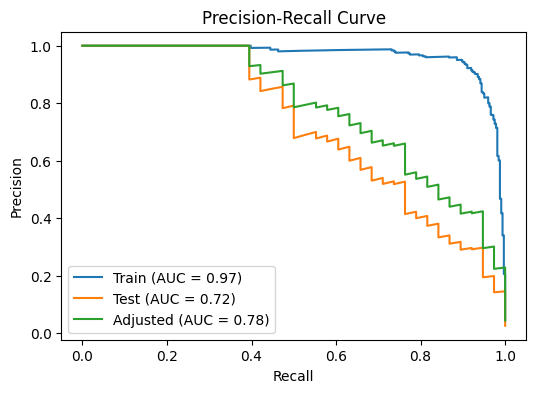

In [66]:
adjusted = adjust_pr_curve_from_roc(
    fpr=roc_auc_dict_test["fpr"],
    tpr=roc_auc_dict_test["tpr"],
    target_prevalence=y_train.value_counts(normalize=True)[True], # Train set prevalence
)
adjusted['name'] = "Adjusted"
pr_auc_dict_test['name'] = "Test"
pr_auc_dict_train['name'] = "Train"
plot_precision_recall_curve([pr_auc_dict_train, pr_auc_dict_test, adjusted])

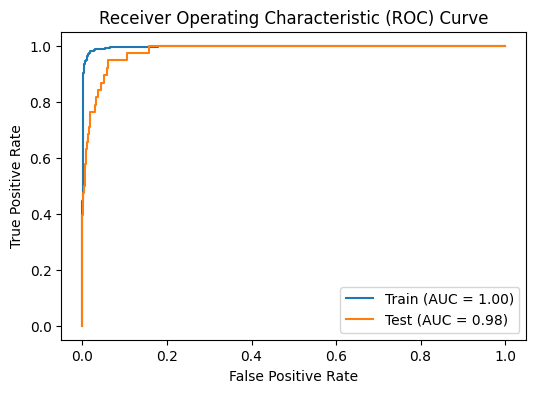

In [67]:
roc_auc_dict_train['name'] = "Train"
roc_auc_dict_test['name'] = "Test"
plot_roc_curve([roc_auc_dict_train, roc_auc_dict_test])

# Feature Selection with L1 Regularization and Feature Importance

**Methodology**: We've decided our hyperparameters for both algorithms. Now we are going to check feature ranks / importances. However we don't want to use directly coefficients and importances of models those trained and evaluated with full train-test sets. **!** We want to use *CV folds' weighted coefficients and importances*, weighted by `test_pr_auc` values of each fold. We would get a more generalized feature coefficients and importances by doing this way. If we think on it; CV folds resembles data variations, but using only one train-test is like just a one scenario / variation.  

**!!!** *Why we use `test_pr_auc` metric, but not `test_pr_auc_adj`?*: When we think about *adjusted PR-AUC*'s definition, using it instead of normal *PR-AUC* would be more fair for each fold's model. Because basically one of fold's test set prevalance might be very low and its contribution to coefficients / importances would be lower and unfair. Reasonable but we want take an executive decision and use `test_pr_auc` for a spesific reason: `test_pr_auc_adj` higher than `test_pr_auc` means that, prevalance of train time interval is higher than test time interval. Means, proportionally more heatwaves. If a model deals with more heatwaves its performance and decisions with data are intuitively more important than models that deal with less heatwaves. In other words, we are counting on models do more work. With this logic, our features might selected according to detect and learn more critical time spaces with more prevalance / heatwaves.

**!** At the end we want to compare two feature sets, set for linear models (Logistic Regression, SVM with linear kernel) and set for non-linear models (Tree based models, SVM with non-linear kernels). For analysis and interpretation purposes. Thus, both should be in same scale. Logistic regressions' are coefficients, spesifically *absolute coefficients*. Tree based models' are importances, which are in percentage scale, in other words they are normalized. In this case, we can basically *normalize logistic regressions' absolute coefficients* too, hence they are in same scale.



## Logistic Regression: L1 Regularization

We are going to use **feature absolute coefficient values** as feature importance. L1-Regularization eliminates collinear features by pulling them down.

Since we need each fold models coefficients, we can't use our CV util function. We have to do it manually.

In [72]:
tscv = TimeSeriesSplit(n_splits=5, test_size=365*2) # Same splits as we used during hyperparameter selection.
records = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X_train)):
    X_train_cv, X_test_cv = X_train.iloc[train_idx], X_train.iloc[test_idx]
    y_train_cv, y_test_cv = y_train.iloc[train_idx], y_train.iloc[test_idx]

    model = LogisticRegression(C=25, penalty="l1", solver="liblinear", random_state=RANDOM_STATE) # Selected model.

    np.random.seed(RANDOM_STATE)
    random.seed(RANDOM_STATE)
    (trained_model, 
    metric_result_train, 
    metric_result_test, 
    artifacts) = train_test_with_groups_and_pca(
        X_train=X_train_cv,
        X_test=X_test_cv,
        y_train=y_train_cv,
        y_test=y_test_cv,
        model=model,
        feature_groups_df=fg_cls,
        non_standardized_features=non_standardized_features,
        metric_fn=get_classification_metrics,
        metric_kwargs={'target_prevalence': y_train.value_counts(normalize=True)[True]}) # For Adjusted PR Curve
    
    records.append({"fold": fold+1})
          
    # Add train and test metrics with prefix
    records[-1].update({'test_'+ k: v for k, v in metric_result_test[0].items()}) 
    records[-1].update({'train_'+ k: v for k, v in metric_result_train[0].items()}) 

    records[-1]["coef"] = trained_model.coef_ # Model coefficients

logreg_coef_df = pd.DataFrame(records)

In [74]:
logreg_coef_df.loc[:, 'coef'] = logreg_coef_df.loc[:, 'coef'].apply(lambda x: x.reshape(-1)) # Flattening 2d array.
logreg_coef_df.loc[:, 'coef_abs'] = np.abs(logreg_coef_df.loc[:, 'coef'])

In [75]:
# Normalizing absolute coefficients
logreg_coef_df.loc[:, 'coef_abs_norm'] = np.divide(logreg_coef_df.loc[:, 'coef_abs'], [np.sum(r) for r in logreg_coef_df.loc[:, 'coef_abs']])

**!** Tree based models' feature importances are normalized from start, hence, before taking weighted average. To make it processes consistent, we normalize absolute coefficients before taking weighted average too.

In [78]:
logreg_coef_df[["fold", "train_pr_auc", "test_pr_auc", "test_pr_auc_adj", "train_roc_auc", "test_roc_auc", "coef", "coef_abs", "coef_abs_norm"]].head()

,fold,train_pr_auc,test_pr_auc,test_pr_auc_adj,train_roc_auc,test_roc_auc,coef,coef_abs,coef_abs_norm
0,1,0.828812,0.753885,0.790853,0.990597,0.979091,"[0.9768615973085707, 0.028766514482646947, -0....","[0.9768615973085707, 0.028766514482646947, 0.3...","[0.01713532378645023, 0.000504599158392405, 0...."
1,2,0.832017,0.690583,0.659595,0.990563,0.964377,"[0.7271268754308213, -0.006041687692648516, -0...","[0.7271268754308213, 0.006041687692648516, 0.0...","[0.013513768094286066, 0.0001122857222519512, ..."
2,3,0.823022,0.700655,0.690833,0.988454,0.975659,"[0.5898081126537242, -0.141966399336519, -0.14...","[0.5898081126537242, 0.141966399336519, 0.1450...","[0.01336619848893247, 0.003217234608308981, 0...."
3,4,0.815821,0.605584,0.575917,0.987808,0.961021,"[0.5761576069118424, -0.18782714088437333, -0....","[0.5761576069118424, 0.18782714088437333, 0.22...","[0.014014239675536623, 0.004568636321636124, 0..."
4,5,0.797359,0.742916,0.748113,0.986184,0.976279,"[1.1940237463614547, -0.11448469198678446, -0....","[1.1940237463614547, 0.11448469198678446, 0.14...","[0.029865136578901944, 0.002863511695473273, 0..."


In [82]:
# Calculating weighted average of normalized absolute coefficients, weighted by 'test_pr_auc' values of each fold.
weighted_coef_avgs = np.average(logreg_coef_df.loc[:, 'coef_abs_norm'], weights=logreg_coef_df.loc[:, 'test_pr_auc'])
weighted_coef_avgs

array([0.01782952, 0.00217716, 0.00380875, 0.03030346, 0.00284982,
       0.00927399, 0.04406513, 0.00280891, 0.00539203, 0.00208311,
       0.0048482 , 0.00102109, 0.00099493, 0.01443706, 0.05140722,
       0.00249283, 0.00586537, 0.0033347 , 0.02236304, 0.01977408,
       0.00377052, 0.0039192 , 0.01248126, 0.01583613, 0.00805546,
       0.0075592 , 0.00969211, 0.00161745, 0.00133088, 0.03654232,
       0.01675239, 0.01032305, 0.00163154, 0.01078173, 0.00546539,
       0.00389308, 0.02089525, 0.003665  , 0.0097412 , 0.00522035,
       0.01017058, 0.01371321, 0.01741542, 0.0378616 , 0.00718302,
       0.00320904, 0.00281154, 0.00142232, 0.00329904, 0.00426082,
       0.02562995, 0.00117124, 0.00329888, 0.00302949, 0.00251759,
       0.03386245, 0.00553102, 0.02580466, 0.01403405, 0.00615035,
       0.00681769, 0.0161296 , 0.00349037, 0.04967244, 0.        ,
       0.02718247, 0.00312477, 0.04093199, 0.00103224, 0.01213148,
       0.00328692, 0.01391542, 0.00944077, 0.00484481, 0.03960

In [83]:
# Sorting indices
coef_sorted_indices = np.argsort(weighted_coef_avgs) 

In [84]:
# List of features
used_features = list(trained_model.feature_names_in_)
logreg_features_sorted = [used_features[i] for i in coef_sorted_indices]

## Graph

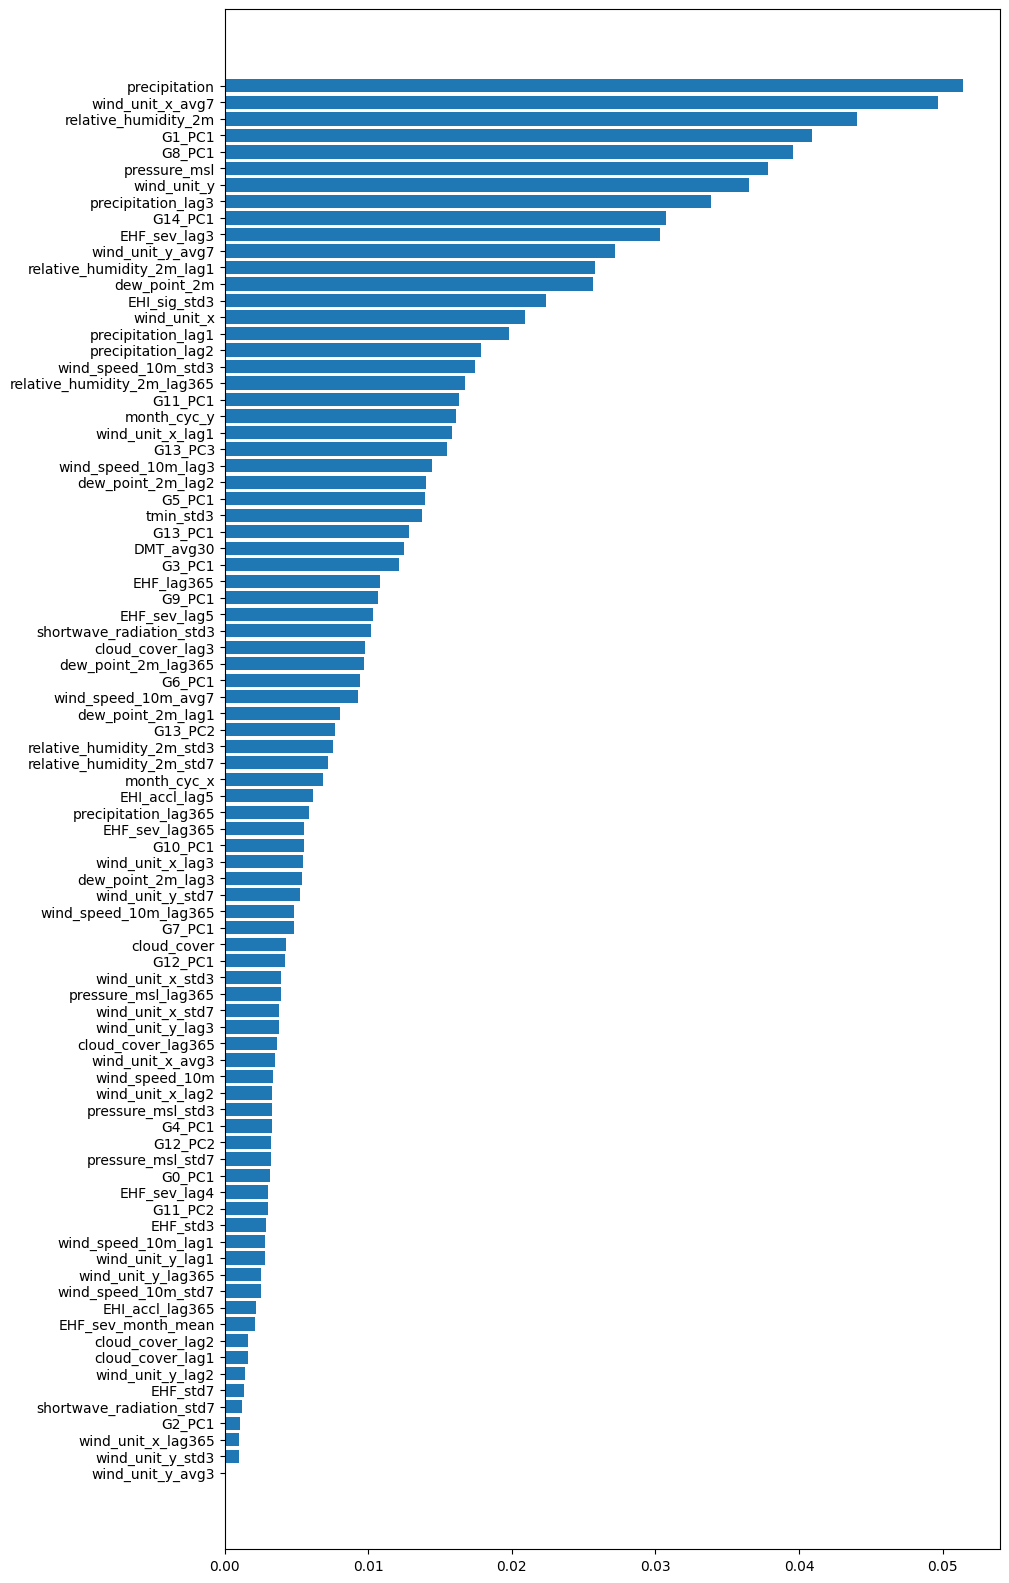

In [85]:
plt.figure(figsize=(10, 20))
plt.barh(logreg_features_sorted, weighted_coef_avgs[coef_sorted_indices], align='center')
plt.show()

If we want to discuss about results very briefly:
* `precipitation` is a very strict about heatwaves as we've seen it during **notebook 05**. 0 precipitation during all heatwaves. This fact is reflected in this graph by taking first order.
* Some of ``wind_unit`` features took place at higher places. Might worth to research more for scientific reasons.
* Importances are not gathered within very few features. They almost linearly decrease after first few features. 

## Gradient Boosting: Tree Feature Importance

We've already discussed the methodology above. Steps are same as Logistic Regression, except that we don't need to normalize or take absolute values. They are already in percentage scale.

In [86]:
tscv = TimeSeriesSplit(n_splits=5, test_size=365*2) 
records = []

In [ ]:
tscv = TimeSeriesSplit(n_splits=5, test_size=365*2) # Same splits as we used during hyperparameter selection.
records = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X_train)):
    X_train_cv, X_test_cv = X_train.iloc[train_idx], X_train.iloc[test_idx]
    y_train_cv, y_test_cv = y_train.iloc[train_idx], y_train.iloc[test_idx]

    model = GradientBoostingClassifier(max_depth=2, n_estimators=100, learning_rate=0.3, random_state=RANDOM_STATE)
    
    np.random.seed(RANDOM_STATE)
    random.seed(RANDOM_STATE)
    (trained_model, 
    metric_result_train, 
    metric_result_test, 
    artifacts) = train_test_with_groups_and_pca(
        X_train=X_train_cv,
        X_test=X_test_cv,
        y_train=y_train_cv,
        y_test=y_test_cv,
        model=model,
        feature_groups_df=fg_cls,
        non_standardized_features=non_standardized_features,
        metric_fn=get_classification_metrics,
        metric_kwargs={'target_prevalence': y_train.value_counts(normalize=True)[True]}) # For Adjusted PR Curve
    
    records.append({"fold": fold+1})
          
    # Add train and test metrics with prefix
    records[-1].update({'test_'+ k: v for k, v in metric_result_test[0].items()}) 
    records[-1].update({'train_'+ k: v for k, v in metric_result_train[0].items()}) 

    records[-1]["feature_importances"] = trained_model.feature_importances_ # Model feature importances

grad_boost_feat_import_df = pd.DataFrame(records)

In [91]:
grad_boost_feat_import_df

,fold,test_recall,test_precision,test_pr_auc,test_roc_auc,test_pr_auc_adj,train_recall,train_precision,train_pr_auc,train_roc_auc,train_pr_auc_adj,feature_importances
0,1,0.521739,0.800000,0.674816,0.981366,0.688453,0.981132,1.000000,1.000000,1.000000,1.000000,"[0.0, 0.0017999975873848667, 0.000857276165911..."
1,2,0.512821,0.769231,0.707685,0.972429,0.668086,0.983516,1.000000,0.999581,0.999980,0.999607,"[0.0, 0.0018429876570721729, 0.002356624376682..."
2,3,0.441176,0.714286,0.614499,0.974349,0.589238,0.950226,1.000000,0.995528,0.999647,0.995605,"[0.0, 0.00553164234159362, 0.0, 0.032139861761..."
3,4,0.368421,0.700000,0.622102,0.957750,0.589013,0.925490,0.987448,0.992055,0.999151,0.992143,"[0.0, 0.0018535199849620367, 0.001951208091934..."
4,5,0.645161,0.714286,0.721818,0.975403,0.725806,0.887372,0.966543,0.979266,0.998128,0.979197,"[0.0, 0.001173831183070976, 0.0, 0.01871436532..."


In [92]:
# Feature importances are already normalized. Calculating directly weighted averages.
weighted_importance_avgs = np.average(grad_boost_feat_import_df.loc[:, 'feature_importances'], 
                                      weights=logreg_coef_df.loc[:, 'test_pr_auc'])
weighted_importance_avgs

array([0.00000000e+00, 2.43300977e-03, 9.89045730e-04, 2.33857834e-02,
       5.80572258e-02, 8.00691565e-05, 1.28622288e-02, 5.81629133e-04,
       2.07721527e-04, 1.91518952e-02, 7.31940405e-04, 5.97971488e-04,
       7.33770666e-03, 3.82247570e-04, 0.00000000e+00, 9.79582017e-04,
       7.31801796e-04, 5.64262926e-03, 7.17220587e-02, 0.00000000e+00,
       4.11304118e-03, 1.21934541e-03, 5.70355513e-03, 8.03923460e-04,
       3.28338777e-03, 6.57484144e-03, 1.87878485e-03, 1.30378556e-03,
       1.61231858e-02, 4.66332624e-02, 1.88779862e-03, 5.88246260e-03,
       1.81979844e-03, 2.76395074e-03, 4.40271979e-03, 9.76359595e-04,
       3.85567444e-03, 1.80371985e-03, 3.40727231e-03, 3.23715122e-03,
       1.77048133e-03, 2.02200106e-03, 1.10030662e-03, 4.13267642e-02,
       4.95241102e-03, 6.99959291e-03, 1.34166566e-04, 3.25029315e-03,
       3.70700428e-03, 2.81467750e-02, 3.23498714e-03, 1.90250360e-03,
       9.46273333e-04, 1.90249007e-02, 8.13681821e-04, 8.15447615e-04,
      

In [ ]:
# Sorting indices
importance_sorted_indices = np.argsort(weighted_importance_avgs) 

In [94]:
# List of features
used_features = list(trained_model.feature_names_in_)
gradboost_features_sorted = [used_features[i] for i in importance_sorted_indices]

## Graph

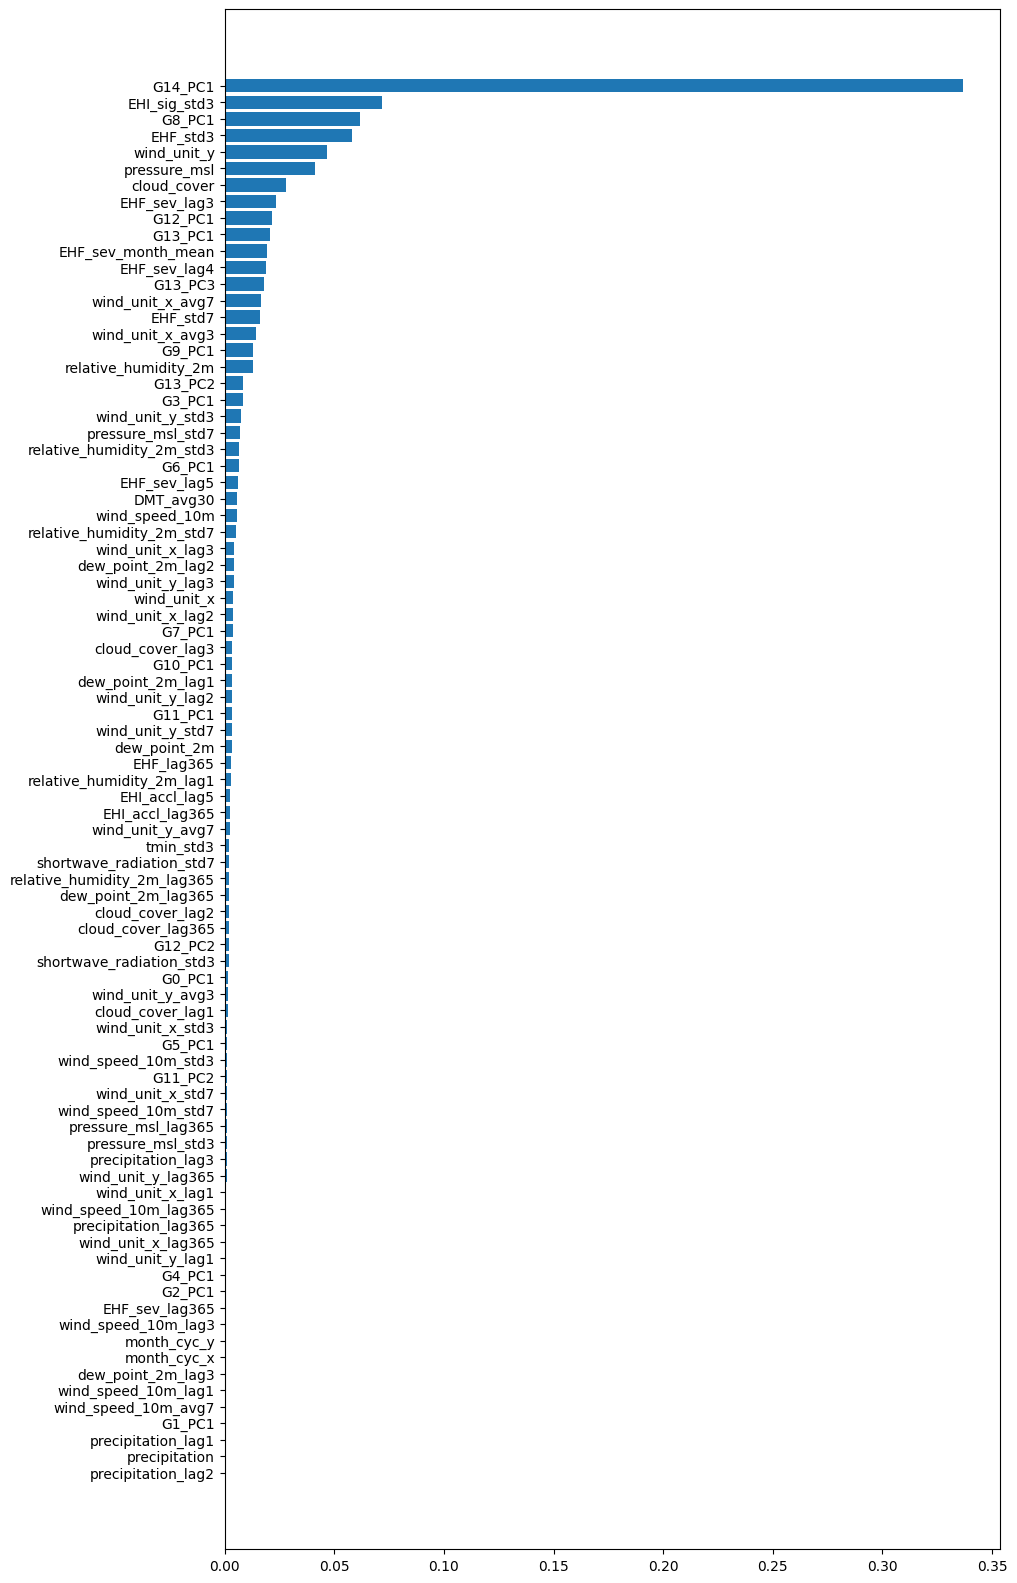

In [96]:
plt.figure(figsize=(10, 20))
plt.barh(gradboost_features_sorted, weighted_importance_avgs[importance_sorted_indices], align='center')
plt.show()

Now as we can see at first glance, this is different than Logistic Regression importances. `G14_PC1` has taken the biggest slice of the cake with ~0.34. After that importances directly drops under 0.1. And values have almost got to 0 without even features have got half of them. If we check the **featur group 14**,

In [4]:
fg_cls.loc[14, 'feature_group']

"['apparent_temperature', 'tmax']"

Now, it is understandable that, model benefitted a lot from most relavant features by using its non-linear abilities. Thus, it doesn't need to use others as logistic regression does.

# Analyses of Feature Importances 
We are going to take two sets' average ranks and put them order. By that, we are going to analyze features in terms of whether which type of features have got higher ranks or lower ranks. Then, we are going to select two sets of features for linear and non-linear models.



**Rank 1 = worst, Rank n = best**

In [105]:
# Number of features
n_features = len(logreg_features_sorted)

# Create rank mappings

logreg_ranks = {feat: rank for rank, feat in enumerate(logreg_features_sorted, start=1)}
gradboost_ranks = {feat: rank for rank, feat in enumerate(gradboost_features_sorted, start=1)}

# Build DataFrame
rank_df = pd.DataFrame({
    "feature": logreg_features_sorted,
    "logreg_rank": [logreg_ranks[f] for f in logreg_features_sorted],
    "gradboost_rank": [gradboost_ranks[f] for f in logreg_features_sorted],
})

# Sort by average rank (purely for nicer ordering)
rank_df["avg_rank"] = rank_df[["logreg_rank", "gradboost_rank"]].mean(axis=1)
rank_df = rank_df.sort_values("avg_rank").reset_index(drop=True) 
rank_df.sort_values("avg_rank", ascending=False)
# Original sorted in ascending order to display plot more conveniently

,feature,logreg_rank,gradboost_rank,avg_rank
84,G8_PC1,81,83,82.0
83,G14_PC1,77,85,81.0
82,pressure_msl,80,80,80.0
81,wind_unit_y,79,81,80.0
80,wind_unit_x_avg7,84,72,78.0
...,...,...,...,...
4,wind_unit_y_avg3,1,30,15.5
3,wind_unit_y_lag1,14,14,14.0
2,wind_speed_10m_lag1,15,6,10.5
1,wind_unit_x_lag365,3,15,9.0


**Caution!:** As rank increases, feature importance increases.

Let's display them on a lollipop chart for a better visualization and analysis.

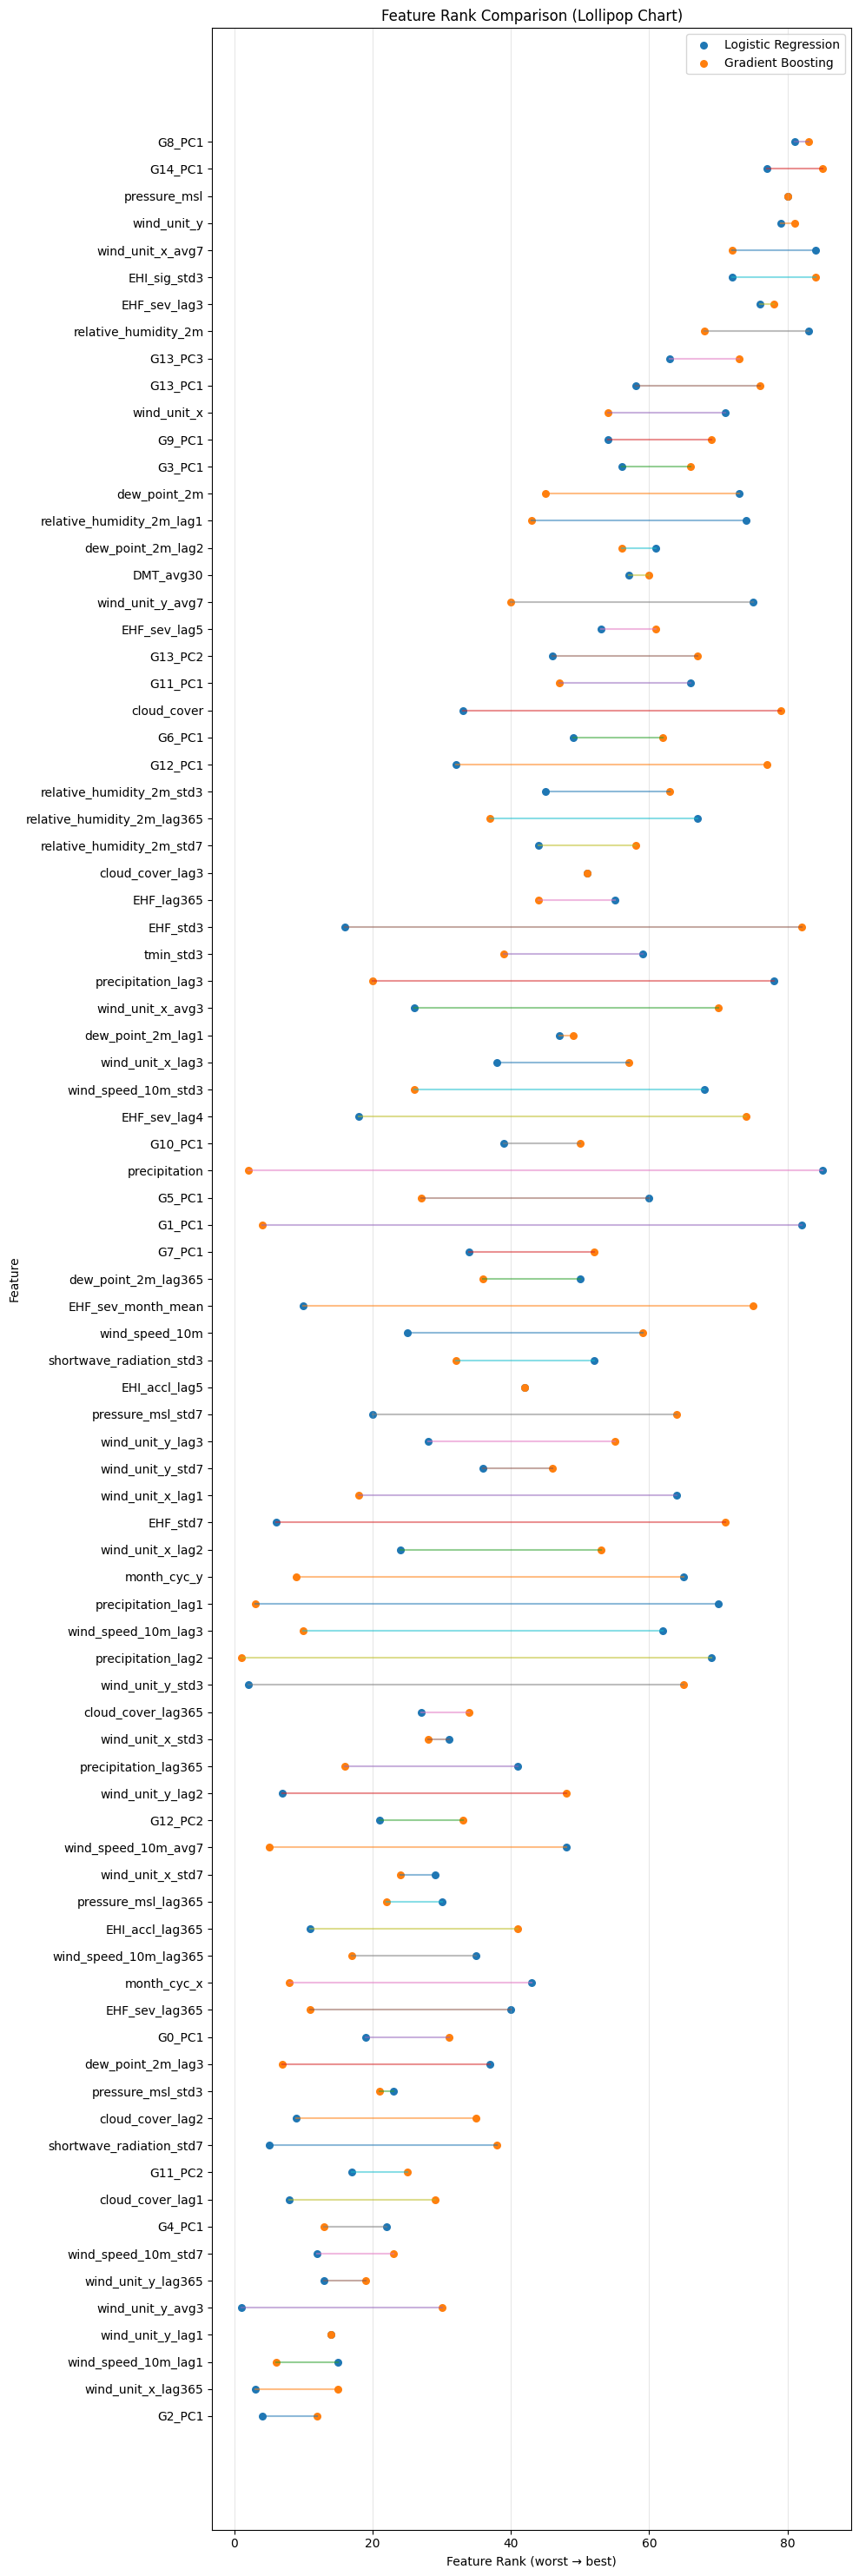

In [107]:
plt.figure(figsize=(10, 0.35 * n_features))  # height scales with feature count

y_pos = range(len(rank_df))

# Connecting lines
for i, row in rank_df.iterrows():
    plt.plot(
        [row["logreg_rank"], row["gradboost_rank"]],
        [i, i],
        alpha=0.5
    )

# Points
plt.scatter(rank_df["logreg_rank"], y_pos, label="Logistic Regression", s=30)
plt.scatter(rank_df["gradboost_rank"], y_pos, label="Gradient Boosting", s=30)

# Axes & labels
plt.yticks(y_pos, rank_df["feature"])
plt.xlabel("Feature Rank (worst → best)")
plt.ylabel("Feature")
plt.title("Feature Rank Comparison (Lollipop Chart)")
plt.legend()
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

**Analyses and Interpretations:**

* Most of the highest rank features, PCs inclueded, are related directly with either temperature or heatwave indices. Like: `G8_PC1, G14_PC1, EHI_sig_std3, EHF_sev_lag3, G13_PC3(and)1, G9_PC1, G3_PC1`. If we put PC groups below:
    - **G8:** *['EHF_lag3', 'EHF_avg3', 'EHF_avg7']*
    - **G14:** *['apparent_temperature', 'tmax']*
    - **G13:** *['wet_bulb_temperature_2m', 'apparent_temperature_lag1', 'apparent_temperature_lag2', 'apparent_temperature_lag3', 'wet_bulb_temperature_2m_lag1', 'wet_bulb_temperature_2m_lag2', 'wet_bulb_temperature_2m_lag3', 'DMT_lag1', 'DMT_lag2', ... ]* It goes on. This is the biggest group with total 33 features. Most of them directly related with temperature or heatwave indices. Rest are related with temperature plus humidity (like ``wet_bulb_temperature_2m`` features).
    - **G9:** *['EHF_lag4', 'EHF_lag5']*
    - **G3:** *['EHI_accl_lag3', 'EHI_accl_lag4']*
* *Humidity* or *humidity plus temperature related* features also have taken some places in first quarter. `relative_humidity_2m`, `dew_point_2m` etc. Which means models catch some humidity related patterns about heatwaves.
* `wind_speed` features are not very effective for both type of models. They are gathered at mostly lower ranks. `G2_PC1`'s features: *['wind_speed_10m_lag2', 'wind_speed_10m_avg3']*. Highest of them are `wind_speed_10m_std3` and `wind_speed_10m` in order. Former has decent importance for logistic regression, while the latter is not effective for gradient boosting because of their lower rank importances very low.
* It seems **notebook 06**'s end decision of adding `DMT_30avg` to list was good. It's got a decent importance for both type of models at transition of 1st and 2nd quarters.
* Most of ``wind_unit`` features are distributed through lower 3 quarters. Except a few like `wind_unit_y, wind_unit_x_avg7, wind_unit_x, wind_unit_y_avg7`. Which means, today's and current weeks' winds might effect on if it's a heatwave or not. Might worth to research more for scientific reasons.
* `month_cyc` features are not higher ranks. Most likely reason is models catch month related patterns from other features directly. As we might remember from **notebook 05**, almost all root features have yearly seasonality.

We've done first / main analyses and interpretations above. It can be extended into more detailed survey in case of interest.

# Feature Selection

We are going to take a simple, but yet effective approach for feature selection. We are going to take out both lists worst 2.5% part, and use both sets with associated type of algorithms. We can use our sorted normalized absolute coefficients and feature importances for the processes.

In [152]:
print("Linears Worst 15 Importance Sum: ", weighted_coef_avgs[coef_sorted_indices][:15].sum().round(3))
print("Non-Linears Worst 33 Importance Sum: ", weighted_importance_avgs[importance_sorted_indices][:33].sum().round(3))

Linears Worst 15 Importance Sum:  0.025
Non-Linears Worst 33 Importance Sum:  0.025


What this means is Logistic Regression's *worst 15 features*, and Gradient Boosting's *worst 33 features* approximately consist of total feature importance's 2.5% in themselves. We are not going to use those features with associated models. Reasons for we're decreasing feature counts are:
- To make model generalization more efficient, spesifically for nonlinear models. They overfit more than linear models.
- To make the models more interpretable.
- To remove multicollinearity, especially for linear models.
- To make model selection more efficient, and use resources more efficiently.

In [ ]:
# Prodcucing boolean columns for features whether inclueded or excluded in linear and nonlinear sets.
rank_df['linear_feat'] = rank_df['logreg_rank'] >= 15 
rank_df['nonlinear_feat'] = rank_df['gradboost_rank'] >= 33
print(f"Linear features count: {rank_df['linear_feat'].sum()}")
print(f"Nonlinear features count: {rank_df['nonlinear_feat'].sum()}")

Linear features count: 71
Nonlinear features count: 53


Linear features count has dropped to 71, while nonlinear features count has dropped to 53. Both are more manageable compared to first potential feature count, more than 140. Its halved for linear models, and almost one third for nonlinear models. But, still we keep 97.5% of total information for both set. 

In [7]:
rank_df

,feature,logreg_rank,gradboost_rank,avg_rank,linear_feat,nonlinear_feat
0,G2_PC1,4,12,8.0,False,False
1,wind_unit_x_lag365,3,15,9.0,False,False
2,wind_speed_10m_lag1,15,6,10.5,True,False
3,wind_unit_y_lag1,14,14,14.0,False,False
4,wind_unit_y_avg3,1,30,15.5,False,False
...,...,...,...,...,...,...
80,wind_unit_x_avg7,84,72,78.0,True,True
81,wind_unit_y,79,81,80.0,True,True
82,pressure_msl,80,80,80.0,True,True
83,G14_PC1,77,85,81.0,True,True


In [ ]:
rank_df.to_csv('data/modelling_info/feature_rank_df.csv', index=False) 

Finally, we are saving this dataframe to use it during model selection and after that.